# Assignment 2 v7 — Adaptive Rotation + Real ML Pipeline----V2
## GR5398 Spring 2026 · FinRL-Trading



In [1]:
import sys, os, warnings, contextlib, io
warnings.filterwarnings('ignore')

import pandas as pd
import numpy  as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates
import matplotlib.patches as mpatches

from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    HistGradientBoostingRegressor, StackingRegressor
)
from sklearn.linear_model   import Ridge
from sklearn.preprocessing  import StandardScaler
from sklearn.metrics        import mean_squared_error

try:
    from xgboost  import XGBRegressor;  HAS_XGB  = True
except ImportError: HAS_XGB  = False
try:
    from lightgbm import LGBMRegressor; HAS_LGBM = True
except ImportError: HAS_LGBM = False

V7_DIR    = '/Users/hhhhwm/Desktop/ai4fin/hw2/v7'
FUND_CSV  = f'{V7_DIR}/data/fundamental_data_full.csv'
SP500_CSV = f'{V7_DIR}/data/sp500_historical_constituents.csv'
ML_CACHE  = f'{V7_DIR}/ml_preds_v7.csv'

SECTOR_TO_BUCKET = {
    'information technology': 'growth_tech', 'technology': 'growth_tech',
    'communication services': 'growth_tech',
    'consumer discretionary': 'cyclical',    'consumer cyclical': 'cyclical',
    'financials': 'cyclical',                'financial services': 'cyclical',
    'industrials': 'cyclical',
    'energy': 'real_assets',                 'materials': 'real_assets',
    'basic materials': 'real_assets',        'real estate': 'real_assets',
    'health care': 'defensive',              'healthcare': 'defensive',
    'consumer staples': 'defensive',         'consumer defensive': 'defensive',
    'utilities': 'defensive',
}
BUCKETS = ['growth_tech', 'cyclical', 'real_assets', 'defensive']

FEATURE_COLS = [
    'pe','ps','pb','peg','ev_multiple',
    'EPS','roe','gross_margin','operating_margin',
    'fcf_per_share','cash_per_share','capex_per_share','fcf_to_ocf','ocf_ratio',
    'debt_ratio','debt_to_equity','debt_to_mktcap',
    'cur_ratio',
    'acc_rec_turnover','asset_turnover','payables_turnover',
    'interest_coverage','debt_service_coverage',
    'dividend_yield','solvency_ratio','BPS',
]
MOMENTUM_COLS = ['ret_1q','ret_4q','ret_accel','eps_chg','roe_chg','gm_chg','om_chg']

DL_START = '2014-01-01'
DL_END   = '2026-01-02'
BT_START = '2018-01-01'

GROWTH_TECH = ['AAPL','MSFT','NVDA','META','AMZN','GOOGL','TSLA']
REAL_ASSETS = ['XOM','CVX','FCX','BHP','GLD','SLV']
DEFENSIVE_A = ['TLT','IEF','XLU','XLV','IAU','SHY','UUP']
DEFAULT_A   = ['SPY','QQQ','IAU','XLU','XLV']

print('Setup complete.')
print(f'XGBoost: {HAS_XGB}  |  LightGBM: {HAS_LGBM}')

Setup complete.
XGBoost: True  |  LightGBM: True


In [2]:
fund = pd.read_csv(FUND_CSV)

fund = fund.rename(columns={'ticker': 'tic'})
fund['datadate'] = pd.to_datetime(fund['datadate'])
fund['tic']      = fund['tic'].astype(str).str.strip()

fund['bucket'] = fund['gsector'].str.lower().map(SECTOR_TO_BUCKET)
fund = fund.dropna(subset=['bucket'])

fund = fund.sort_values(['tic','datadate']).reset_index(drop=True)

fund['ret_1q']   = fund.groupby('tic')['trade_price'].pct_change(1)
fund['ret_2q']   = fund.groupby('tic')['trade_price'].pct_change(2)
fund['ret_4q']   = fund.groupby('tic')['trade_price'].pct_change(4)
fund['ret_accel']= fund['ret_1q'] - fund['ret_2q']

for col, new_col in [('EPS','eps_chg'),('roe','roe_chg'),
                     ('gross_margin','gm_chg'),('operating_margin','om_chg')]:
    if col in fund.columns:
        fund[new_col] = fund.groupby('tic')[col].pct_change(1)

sector_dummies = pd.get_dummies(fund['gsector'], prefix='sector')
SECTOR_COLS    = sector_dummies.columns.tolist()
fund = pd.concat([fund, sector_dummies], axis=1)

avail_feat = [c for c in FEATURE_COLS + MOMENTUM_COLS + SECTOR_COLS
              if c in fund.columns]

fund[avail_feat] = (
    fund[avail_feat]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(fund[avail_feat].median())
)
for c in FEATURE_COLS + MOMENTUM_COLS:
    if c in fund.columns:
        lo, hi = fund[c].quantile([0.01, 0.99])
        fund[c] = fund[c].clip(lo, hi)

print(f'Loaded: {fund.shape}')
print(f'Date range: {fund["datadate"].min().date()} → {fund["datadate"].max().date()}')
print(f'Tickers: {fund["tic"].nunique()}   Buckets:')
print(fund['bucket'].value_counts())
print(f'Features used: {len(avail_feat)}')

Loaded: (22909, 84)
Date range: 2015-06-30 → 2026-03-31
Tickers: 715   Buckets:
bucket
cyclical       9557
defensive      5468
growth_tech    4258
real_assets    3626
Name: count, dtype: int64
Features used: 44


In [3]:
def build_models():
    m = {
        'RF':       RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1),
        'HistGBM':  HistGradientBoostingRegressor(max_iter=100, max_depth=6, learning_rate=0.05, random_state=42),
        'ExtraTrees': ExtraTreesRegressor(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1),
        'Ridge':    Ridge(alpha=1.0),
    }
    if HAS_XGB:  m['XGB']  = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.05, random_state=42, verbosity=0)
    if HAS_LGBM: m['LGBM'] = LGBMRegressor(n_estimators=100, max_depth=6, learning_rate=0.05, random_state=42, verbose=-1)
    return m

def run_one_quarter(bdf, feature_cols, val_end_idx, all_dates, val_q=2):
    """Train on data up to all_dates[val_end_idx], predict all_dates[val_end_idx+1]."""
    val_start = max(0, val_end_idx - val_q + 1)
    val_dates = set(all_dates[val_start : val_end_idx + 1])
    if val_end_idx + 1 >= len(all_dates):
        return pd.DataFrame()
    infer_date = all_dates[val_end_idx + 1]

    train_b = bdf[(~bdf['datadate'].isin(val_dates)) &
                  (bdf['datadate'] <= all_dates[val_end_idx]) &
                  (bdf['y_return'].notna())]
    val_b   = bdf[bdf['datadate'].isin(val_dates) & bdf['y_return'].notna()]
    infer_b = bdf[bdf['datadate'] == infer_date].copy()

    if len(train_b) < 30 or len(infer_b) == 0:
        return pd.DataFrame()

    X_tr, y_tr = train_b[feature_cols].values, train_b['y_return'].values
    X_val      = val_b[feature_cols].values   if len(val_b) > 0 else None
    y_val      = val_b['y_return'].values     if len(val_b) > 0 else None
    X_inf      = infer_b[feature_cols].values

    scaler   = StandardScaler()
    X_tr_s   = scaler.fit_transform(X_tr)
    X_val_s  = scaler.transform(X_val) if X_val is not None else None
    X_inf_s  = scaler.transform(X_inf)

    models  = build_models()
    fitted, mse_map = {}, {}
    for name, mdl in models.items():
        mdl.fit(X_tr_s, y_tr)
        fitted[name] = mdl
        mse_map[name] = (mean_squared_error(y_val, mdl.predict(X_val_s))
                         if X_val_s is not None and len(X_val_s) > 0 else 1.0)

    top3 = sorted(mse_map, key=mse_map.get)[:3]
    stk  = StackingRegressor(
        estimators=[(n, fitted[n]) for n in top3],
        final_estimator=Ridge(alpha=1.0), cv=3, n_jobs=-1
    )
    with contextlib.redirect_stdout(io.StringIO()):
        stk.fit(X_tr_s, y_tr)
    fitted['Stacking'] = stk
    mse_map['Stacking'] = (mean_squared_error(y_val, stk.predict(X_val_s))
                           if X_val_s is not None and len(X_val_s) > 0 else 1.0)

    best_name = min(mse_map, key=mse_map.get)

    inv_w  = {n: 1/m if m > 0 else 0 for n, m in mse_map.items()}
    total_w = sum(inv_w.values())

    infer_b['predicted_return'] = fitted[best_name].predict(X_inf_s)
    infer_b['pred_ensemble']    = (sum((inv_w[n]/total_w) * fitted[n].predict(X_inf_s)
                                       for n in fitted)
                                   if total_w > 0 else infer_b['predicted_return'])
    infer_b['best_model'] = best_name
    return infer_b[['tic','datadate','bucket','predicted_return','pred_ensemble','best_model']]

if os.path.exists(ML_CACHE):
    print('Loading cached ML predictions ...')
    ml_preds = pd.read_csv(ML_CACHE, parse_dates=['datadate'])
else:
    print('Running rolling walk-forward ML (4 buckets × all quarters) ...')
    all_quarters = sorted(fund['datadate'].unique())
    MIN_TRAIN_Q  = 8

    all_rows = []
    total = (len(all_quarters) - MIN_TRAIN_Q - 1) * len(BUCKETS)
    done  = 0

    for i in range(MIN_TRAIN_Q, len(all_quarters) - 1):
        for bucket in BUCKETS:
            done += 1
            print(f'\r  [{done}/{total}] Q={all_quarters[i].date()} bucket={bucket:<12}', end='')
            bdf  = fund[fund['bucket'] == bucket].copy()
            feat = [c for c in avail_feat if c in bdf.columns]
            rows = run_one_quarter(bdf, feat, i, all_quarters, val_q=2)
            if len(rows) > 0:
                all_rows.append(rows)

    ml_preds = pd.concat(all_rows, ignore_index=True)
    ml_preds.to_csv(ML_CACHE, index=False)
    print(f'\nSaved → {ML_CACHE}')

print(f'\nML predictions: {ml_preds.shape}')
print(f'Date range: {ml_preds["datadate"].min().date()} → {ml_preds["datadate"].max().date()}')
print(ml_preds['bucket'].value_counts())

Running rolling walk-forward ML (4 buckets × all quarters) ...
  [140/140] Q=2025-12-31 bucket=defensive   
Saved → /Users/hhhhwm/Desktop/ai4fin/hw2/v7/ml_preds_v7.csv

ML predictions: (19591, 6)
Date range: 2017-09-30 → 2026-03-31
bucket
cyclical       8234
defensive      4647
growth_tech    3649
real_assets    3061
Name: count, dtype: int64


In [4]:
DATADATE_TO_TRADEDATE = {
    '03-31': ('06-01', 0), '06-30': ('09-01', 0),
    '09-30': ('12-01', 0), '12-31': ('03-01', 1),
}

def datadate_to_tradedate(d):
    s = str(d)[:10]
    mm_dd = s[5:]
    year  = int(s[:4])
    mapping = DATADATE_TO_TRADEDATE.get(mm_dd)
    if not mapping: return None
    td_mmdd, yr_add = mapping
    return pd.Timestamp(f'{year+yr_add}-{td_mmdd}')

ml_preds['tradedate'] = ml_preds['datadate'].apply(datadate_to_tradedate)
ml_preds = ml_preds.dropna(subset=['tradedate'])

ml_weekly = {}
ML_START  = {}

for bucket in BUCKETS:
    bp = ml_preds[ml_preds['bucket'] == bucket].copy()
    pivot = bp.pivot_table(index='tradedate', columns='tic',
                           values='pred_ensemble', aggfunc='last')
    pivot = pivot.sort_index()
    bday  = pd.bdate_range(pivot.index.min(), '2027-01-01')
    daily = pivot.reindex(bday).ffill()
    weekly = daily.resample('W-FRI').last()
    ml_weekly[bucket] = weekly
    ML_START[bucket]  = weekly.dropna(how='all').index[0]
    print(f'  {bucket:<14}: {weekly.shape}  first={ML_START[bucket].date()}')

ML_TOP_N = 15

BUCKET_FALLBACK = {
    'growth_tech': ['AAPL','MSFT','NVDA','META','AMZN','GOOGL','TSLA'],
    'real_assets': ['XOM','CVX','GLD','FCX','SLV','BHP'],
    'defensive':   ['JNJ','PG','KO','WMT','XLV','UNH'],
    'cyclical':    ['JPM','BAC','HD','AMZN','COST','V'],
}

def get_ml_pool(date, bucket, top_n=ML_TOP_N, prices_daily=None, sma_window=200):
    """ML top-N for a bucket, filtered by individual stock SMA-200."""
    wk = ml_weekly.get(bucket)
    if wk is None or date < ML_START.get(bucket, pd.Timestamp('2099-01-01')):
        fb = [t for t in BUCKET_FALLBACK.get(bucket, []) if prices_daily is None or t in prices_daily.columns]
        return fb[:top_n], 'fallback'
    row = wk.loc[:date].iloc[-1].dropna()
    candidates = row.nlargest(top_n).index.tolist()
    if prices_daily is None:
        return candidates, 'ml'
    valid = []
    for t in candidates:
        if t not in prices_daily.columns: continue
        h = prices_daily[t].loc[:date].dropna()
        if len(h) < sma_window or h.iloc[-1] > h.tail(sma_window).mean():
            valid.append(t)
    return (valid if valid else candidates[:5]), 'ml'

print('\nML pool helpers ready.')

  growth_tech   : (475, 147)  first=2017-12-01
  cyclical      : (475, 288)  first=2017-12-01
  real_assets   : (475, 105)  first=2017-12-01
  defensive     : (475, 160)  first=2017-12-01

ML pool helpers ready.


In [5]:
REGIME_TICKERS = ['SPY', 'HYG', 'IEF', 'TLT', 'SHY', 'GLD', 'XLV', 'XLU', 'QQQ',
                  'IAU', 'SLV', 'UUP', 'XOM', 'CVX', 'FCX']
VIX_TICKER     = ['^VIX']

ML_TICKERS = sorted(set(
    t for b in BUCKETS
    for t in ml_weekly[b].dropna(how='all', axis=1).columns
    if isinstance(t, str) and t.isalpha() and len(t) <= 5
))

ALL_DL = sorted(set(GROWTH_TECH + REAL_ASSETS + DEFENSIVE_A + DEFAULT_A
                    + REGIME_TICKERS + ML_TICKERS))

print(f'Downloading {len(ALL_DL)} tickers + VIX ...')
raw_px  = yf.download(ALL_DL,       start=DL_START, end=DL_END, auto_adjust=True, progress=False)
raw_vix = yf.download(VIX_TICKER,   start=DL_START, end=DL_END, auto_adjust=True, progress=False)

prices_daily  = raw_px['Close'].dropna(how='all', axis=1).ffill()
if isinstance(raw_vix['Close'], pd.Series):
    prices_daily['VIX'] = raw_vix['Close'].reindex(prices_daily.index).ffill()
else:
    prices_daily['VIX'] = raw_vix['Close']['^VIX'].reindex(prices_daily.index).ffill()

prices_weekly = prices_daily.drop(columns=['VIX']).resample('W-FRI').last()
weekly_ret    = prices_weekly.pct_change().dropna(how='all')

print(f'Daily prices : {prices_daily.shape}')
print(f'Weekly prices: {prices_weekly.shape}')
print(f'VIX range    : {prices_daily["VIX"].dropna().iloc[0]:.1f} → {prices_daily["VIX"].dropna().iloc[-1]:.1f}')

$SWN: possibly delisted; no timezone found
$CXO: possibly delisted; no timezone found
$FLT: possibly delisted; no timezone found
$AGN: possibly delisted; no timezone found
$IPG: possibly delisted; no timezone found
$BLL: possibly delisted; no timezone found
$XL: possibly delisted; no timezone found
$RTN: possibly delisted; no timezone found
$FI: possibly delisted; no timezone found
$CDAY: possibly delisted; no timezone found
$PEAK: possibly delisted; no timezone found
$SIVB: possibly delisted; no timezone found
$CMA: possibly delisted; no timezone found
$VAR: possibly delisted; no timezone found
$CTL: possibly delisted; no timezone found
$DISCK: possibly delisted; no timezone found
$TWTR: possibly delisted; no timezone found
$TIF: possibly delisted; no timezone found
$ADS: possibly delisted; no timezone found
$CBS: possibly delisted; no timezone found
$ABMD: possibly delisted; no timezone found
$DO: possibly delisted; no timezone found
$K: possibly delisted; no timezone found
$DISCA: p

Daily prices : (3018, 613)
Weekly prices: (627, 612)
VIX range    : 14.2 → 14.9


Multi-factor regime distribution (2=bull, 1=neutral, 0=bear):
0    117
1    125
2    384
Name: count, dtype: int64

SMA-200 regime (1=bull, 0=bear):
SPY
0    146
1    480
Name: count, dtype: int64


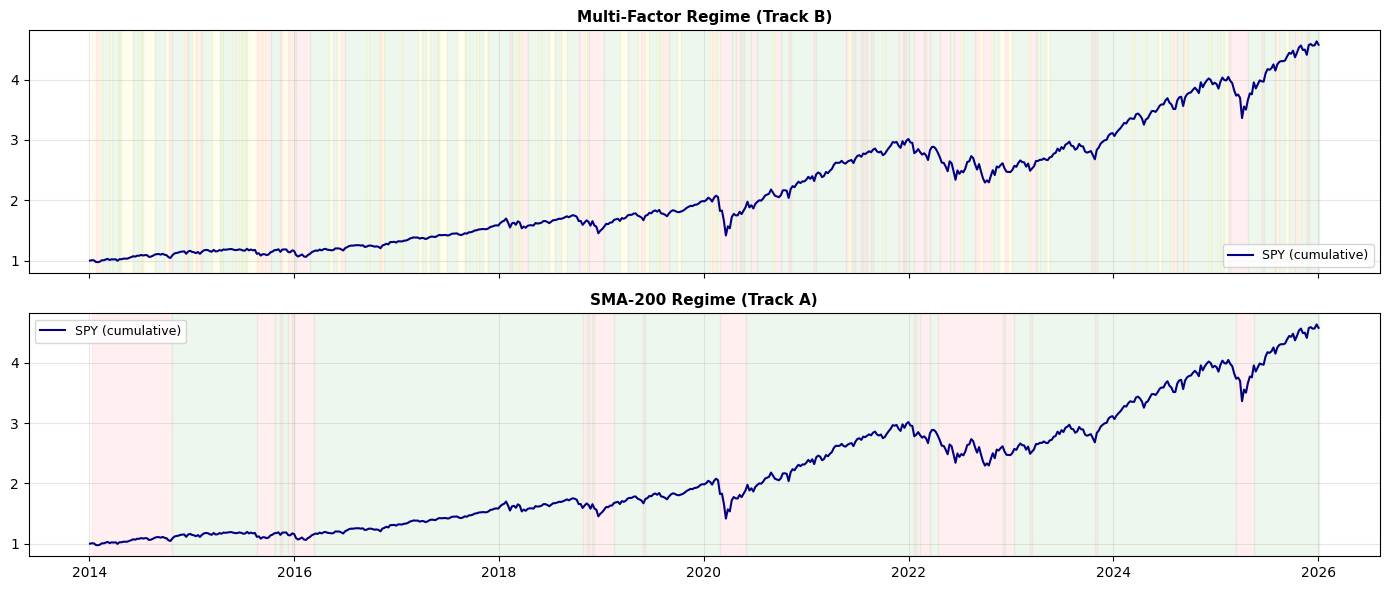

In [6]:
def get_multi_factor_regime(prices_daily, weekly_index):
    sig = pd.DataFrame(index=prices_daily.index)

    spy_ret = prices_daily['SPY'].pct_change(20)
    sig['spy_mom'] = np.where(spy_ret > 0.03, 1, np.where(spy_ret < -0.03, -1, 0))

    if 'VIX' in prices_daily.columns:
        vix = prices_daily['VIX']
        sig['vix'] = np.where(vix < 18, 1, np.where(vix > 28, -1, 0))
    else:
        sig['vix'] = 0

    if 'HYG' in prices_daily.columns and 'IEF' in prices_daily.columns:
        ratio    = prices_daily['HYG'] / prices_daily['IEF']
        ratio_ma = ratio.rolling(20).mean()
        sig['credit'] = np.where(ratio > ratio_ma, 1, -1)
    else:
        sig['credit'] = 0

    composite = 0.35 * sig['spy_mom'] + 0.35 * sig['vix'] + 0.30 * sig['credit']
    regime_d  = composite.apply(lambda x: 2 if x > 0.25 else (0 if x < -0.25 else 1))
    regime_w  = regime_d.resample('W-FRI').last().reindex(weekly_index, method='ffill')
    return regime_w.fillna(1).astype(int)

def get_sma200_regime(spy_daily, weekly_index, window=200):
    sma    = spy_daily.rolling(window).mean()
    bull   = (spy_daily > sma).astype(int)
    return bull.resample('W-FRI').last().reindex(weekly_index, method='ffill').fillna(0).astype(int)

multi_regime = get_multi_factor_regime(prices_daily, weekly_ret.index)
sma_regime   = get_sma200_regime(prices_daily['SPY'], weekly_ret.index)

print('Multi-factor regime distribution (2=bull, 1=neutral, 0=bear):')
print(multi_regime.value_counts().sort_index())
print('\nSMA-200 regime (1=bull, 0=bear):')
print(sma_regime.value_counts().sort_index())

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
spy_w = prices_weekly['SPY'].pct_change().fillna(0).add(1).cumprod()

for ax, reg, title, colors in [
    (axes[0], multi_regime, 'Multi-Factor Regime (Track B)',
     {2:'#c8e6c9', 1:'#fff9c4', 0:'#ffcdd2'}),
    (axes[1], sma_regime,   'SMA-200 Regime (Track A)',
     {1:'#c8e6c9', 0:'#ffcdd2'}),
]:
    ax.plot(spy_w.index, spy_w.values, color='navy', lw=1.5, label='SPY (cumulative)')
    prev, prev_date = None, spy_w.index[0]
    for date, state in reg.items():
        if state != prev:
            if prev is not None:
                ax.axvspan(prev_date, date, alpha=0.3, color=colors.get(prev,'white'))
            prev, prev_date = state, date
    ax.axvspan(prev_date, spy_w.index[-1], alpha=0.3, color=colors.get(prev,'white'))
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{V7_DIR}/v2_regime.png', dpi=130)
plt.show()

In [7]:
def compute_group_ir(group_ret, spy_ret, window=12):
    if len(group_ret) < window: return -np.inf
    exc = (group_ret - spy_ret).iloc[-window:]
    return exc.mean() / (exc.std() + 1e-9)

def compute_residual_momentum(asset_hist, spy_hist, window=12):
    spy = spy_hist.iloc[-window:].values
    if len(spy) < window: return pd.Series(dtype=float)
    X = np.column_stack([np.ones(window), spy])
    Y = asset_hist.iloc[-window:].values
    valid = ~np.isnan(Y).any(axis=0)
    if not valid.any(): return pd.Series(dtype=float)
    beta, *_ = np.linalg.lstsq(X, Y[:, valid], rcond=None)
    resid = Y[:, valid] - X @ beta
    return pd.Series(resid.sum(axis=0), index=asset_hist.columns[valid])

def get_inv_vol_weights(tickers, date, vol_window=60):
    """Inverse-volatility weights (A1 formula)."""
    vols, valid = [], []
    for t in tickers:
        if t not in prices_daily.columns: continue
        ret = prices_daily[t].pct_change().loc[:date].dropna().tail(vol_window)
        vols.append(max(float(ret.std()) if len(ret) >= 10 else 0.05, 0.01))
        valid.append(t)
    if not valid: return {}
    inv_v = 1.0 / np.array(vols)
    return {t: float(w) for t, w in zip(valid, inv_v / inv_v.sum())}

def get_vol_scalar(date, target_vol=0.15, window=20, cap=1.5, floor=0.3):
    """
    Volatility Targeting: dynamic position scalar.
    scalar = target_vol / realized_vol   (capped at `cap`, floored at `floor`)
    Realized vol = 20-day daily SPY return std, annualised.
    """
    ret = prices_daily['SPY'].pct_change().loc[:date].dropna().tail(window)
    if len(ret) < 5: return 1.0
    rv = ret.std() * np.sqrt(252)
    return float(np.clip(target_vol / rv if rv > 0 else 1.0, floor, cap))

def compute_metrics(nav):
    ret    = nav.pct_change().dropna()
    nyrs   = (nav.index[-1] - nav.index[0]).days / 365.25
    total  = nav.iloc[-1] / nav.iloc[0] - 1
    ann    = (1+total)**(1/nyrs) - 1
    vol    = ret.std() * np.sqrt(52)
    sharpe = ann / vol if vol > 0 else 0
    mdd    = ((nav - nav.cummax()) / nav.cummax()).min()
    calmar = ann / abs(mdd) if mdd != 0 else 0
    return {'Cum. Return': f'{total:+.1%}', 'Ann. Return': f'{ann:+.1%}',
            'Volatility': f'{vol:.1%}', 'Sharpe': f'{sharpe:.2f}',
            'Max DD': f'{mdd:.1%}', 'Calmar': f'{calmar:.2f}'}

print('Helpers defined.')

Helpers defined.


In [8]:
GROUPS_A = {
    'GROWTH_TECH': GROWTH_TECH,
    'REAL_ASSETS':  REAL_ASSETS,
    'DEFENSIVE':    DEFENSIVE_A,
    'DEFAULT':      DEFAULT_A,
}

def run_track_a(weekly_ret, ir_window=12, top_n=2,
                dd_lookback=13, dd_thresh=-0.08, recover=-0.03, tc=0.001):
    regime_s = sma_regime
    BEAR_GRP  = ['DEFENSIVE', 'DEFAULT']
    BONDS     = {'IEF': 0.6, 'SHY': 0.4}
    nav, prev_wts, nav_hist = 1.0, {}, []
    in_ro = False
    nav_list, hold_list = [], []

    for i in range(ir_window+1, len(weekly_ret)):
        date = weekly_ret.index[i]
        if date < pd.Timestamp(BT_START): continue
        hist     = weekly_ret.iloc[i-ir_window-1:i-1]
        spy_hist = hist['SPY'] if 'SPY' in hist else pd.Series(0., index=hist.index)
        regime   = int(regime_s.get(date, 1))

        allowed  = list(GROUPS_A) if regime == 1 else BEAR_GRP
        best_grp = max(allowed, key=lambda g: compute_group_ir(
            hist[[t for t in GROUPS_A[g] if t in hist]].mean(axis=1), spy_hist, ir_window))
        pool = [t for t in GROUPS_A[best_grp] if t in hist and not hist[t].isna().any()]

        res = compute_residual_momentum(hist[pool], spy_hist, ir_window)
        top = res.nlargest(top_n).index.tolist() if len(res) >= top_n else pool[:top_n]
        if not top: top = pool[:1] or ['SPY']

        lk = min(dd_lookback, len(nav_hist))
        pk = max(nav_hist[-lk:]) if nav_hist else nav
        dd = (nav-pk)/pk
        if dd < dd_thresh:   in_ro = True
        elif in_ro and dd > recover: in_ro = False

        eq_wts = {t: 1./len(top) for t in top}
        if in_ro and best_grp not in BEAR_GRP:
            wts  = {t: 0.5*w for t,w in eq_wts.items()}
            wts.update({t: 0.5*bw for t,bw in BONDS.items() if t in weekly_ret})
            mode = 'dd-blend'
        else:
            wts  = eq_wts; mode = 'bull' if regime else 'bear'

        wr    = weekly_ret.iloc[i]
        gross = sum(wts.get(t,0)*wr.get(t,0) for t in wts)
        cost  = tc*sum(abs(wts.get(t,0)-prev_wts.get(t,0)) for t in set(list(wts)+list(prev_wts)))
        nav   = nav*(1+gross-cost)
        nav_hist.append(nav)
        nav_list.append({'date':date,'nav':nav})
        hold_list.append({'date':date,'regime':regime,'group':best_grp,'holdings':','.join(wts),'mode':mode})
        prev_wts = wts.copy()

    ns = pd.DataFrame(nav_list).set_index('date')['nav']
    hs = pd.DataFrame(hold_list).set_index('date')
    return ns/ns.iloc[0], hs

print('run_track_a() defined.')

run_track_a() defined.


In [9]:
BUCKET_TO_GROUP = {
    'growth_tech': 'GROWTH_TECH',
    'real_assets': 'REAL_ASSETS',
    'defensive':   'DEFENSIVE',
    'cyclical':    'CYCLICAL',
}
GROUP_TO_BUCKET = {v: k for k, v in BUCKET_TO_GROUP.items()}

GROUPS_B = ['GROWTH_TECH', 'REAL_ASSETS', 'DEFENSIVE', 'CYCLICAL']

def run_track_b(weekly_ret, ir_window=12, top_n_ml=3,
                target_vol=0.15, tc=0.001):
    """
    Track B: Adaptive Rotation + A1 ML (teacher spec) + multi-factor regime + vol targeting.

    Layer 1  Regime: multi-factor 3-state (bull=2/neutral=1/bear=0)
             bull=2 : all 4 ML groups compete
             neutral=1 : allowed to hold any group
             bear=0 : restrict to DEFENSIVE ML bucket only
    Layer 2  Group IR: 12-week IR using ML pool mean return
    Layer 3  Stock ranking: CAPM residual momentum → top-3 per group
             Weights: inverse volatility (A1 formula)
    Layer 4  Vol Targeting: scalar = min(target_vol/realized_vol, 1.5)
             Remainder → SHY (cash proxy)
    """
    regime_s = multi_regime
    BONDS    = {'IEF': 0.6, 'SHY': 0.4}
    nav, prev_wts, nav_hist = 1.0, {}, []
    nav_list, hold_list = [], []

    for i in range(ir_window+1, len(weekly_ret)):
        date = weekly_ret.index[i]
        if date < pd.Timestamp(BT_START): continue
        hist     = weekly_ret.iloc[i-ir_window-1:i-1]
        spy_hist = hist['SPY'] if 'SPY' in hist else pd.Series(0., index=hist.index)
        regime   = int(regime_s.get(date, 1))

        allowed = GROUPS_B if regime >= 1 else ['DEFENSIVE']

        def _grp_ir(grp):
            bucket = GROUP_TO_BUCKET[grp]
            pool, _ = get_ml_pool(date, bucket, top_n=ML_TOP_N, prices_daily=prices_daily)
            tks = [t for t in pool if t in hist]
            if not tks: return -np.inf
            return compute_group_ir(hist[tks].mean(axis=1), spy_hist, ir_window)

        best_grp = max(allowed, key=_grp_ir)
        bucket   = GROUP_TO_BUCKET[best_grp]

        pool_raw, pool_src = get_ml_pool(date, bucket, top_n=ML_TOP_N, prices_daily=prices_daily)
        pool = [t for t in pool_raw if t in hist and not hist[t].isna().any()]
        if not pool:
            pool = [t for t in pool_raw if t in hist][:top_n_ml]

        res = compute_residual_momentum(hist[pool], spy_hist, ir_window)
        top = res.nlargest(top_n_ml).index.tolist() if len(res) >= top_n_ml else pool[:top_n_ml]
        if not top: top = ['SPY']

        base_wts = get_inv_vol_weights(top, date)
        if not base_wts: base_wts = {t: 1./len(top) for t in top}

        if regime == 0:
            mode = 'bear'
        elif regime == 2:
            mode = 'bull'
        else:
            mode = 'neutral'

        scalar      = get_vol_scalar(date, target_vol=target_vol)
        equity_wts  = {t: w * scalar for t, w in base_wts.items()}
        cash_weight = max(0., 1. - sum(equity_wts.values()))
        wts = equity_wts.copy()
        if cash_weight > 0.02 and 'SHY' in weekly_ret.columns:
            wts['SHY'] = wts.get('SHY', 0.) + cash_weight

        wr    = weekly_ret.iloc[i]
        gross = sum(wts.get(t,0)*wr.get(t,0) for t in wts)
        cost  = tc*sum(abs(wts.get(t,0)-prev_wts.get(t,0)) for t in set(list(wts)+list(prev_wts)))
        nav   = nav*(1+gross-cost)
        nav_hist.append(nav)
        nav_list.append({'date':date,'nav':nav})
        hold_list.append({'date':date,'regime':regime,'group':best_grp,'bucket':bucket,
                          'pool_source':pool_src,'holdings':','.join(top),
                          'vol_scalar':round(scalar,3),'mode':mode})
        prev_wts = wts.copy()

    ns = pd.DataFrame(nav_list).set_index('date')['nav']
    hs = pd.DataFrame(hold_list).set_index('date')
    return ns/ns.iloc[0], hs

print('run_track_b() defined.')

run_track_b() defined.


In [10]:
print('Running Track A (SMA-200, faithful spec) ...')
nav_a, hold_a = run_track_a(weekly_ret)
print(f'  {len(nav_a)} weeks: {nav_a.index[0].date()} → {nav_a.index[-1].date()}')

print('Running Track B (ML + multi-factor regime + vol targeting) ...')
nav_b, hold_b = run_track_b(weekly_ret)
print(f'  {len(nav_b)} weeks: {nav_b.index[0].date()} → {nav_b.index[-1].date()}')

bt_idx = nav_a.index
spy_bm = prices_weekly['SPY'].reindex(bt_idx).ffill()
spy_bm = spy_bm / spy_bm.iloc[0]
qqq_bm = prices_weekly['QQQ'].reindex(bt_idx).ffill()
qqq_bm = qqq_bm / qqq_bm.iloc[0]
print('Done.')

Running Track A (SMA-200, faithful spec) ...
  418 weeks: 2018-01-05 → 2026-01-02
Running Track B (ML + multi-factor regime + vol targeting) ...
  418 weeks: 2018-01-05 → 2026-01-02
Done.


In [11]:
import matplotlib.patches as mpatches

def _raw(nav):
    r = nav.pct_change().dropna()
    n = (nav.index[-1] - nav.index[0]).days / 365.25
    tot = nav.iloc[-1] / nav.iloc[0] - 1
    ann = (1 + tot) ** (1 / n) - 1
    vol = r.std() * np.sqrt(52)
    sh  = ann / vol if vol > 0 else 0
    mdd = ((nav - nav.cummax()) / nav.cummax()).min()
    return [tot, ann, vol, sh, mdd, ann / abs(mdd) if mdd else 0]

STRATS = ['Track A\n(Adaptive Rotation)', 'Track B\n(ML+Regime\n+VolTarget)', 'SPY', 'QQQ']
NAVS   = [nav_a, nav_b, spy_bm, qqq_bm]
COLS   = ['Cum. Return', 'Ann. Return', 'Volatility', 'Sharpe', 'Max DD', 'Calmar']
HIGHER = [True, True, False, True, False, True]
COLORS = ['#2196F3', '#7B1FA2', '#757575', '#43A047']

raw = np.array([_raw(n) for n in NAVS])
fmt = [[f"{v:+.1%}" if i in (0,1,2,4) else f"{v:.2f}"
        for i, v in enumerate(row)] for row in raw]

best  = [np.argmax(raw[:,j]) if HIGHER[j] else np.argmin(raw[:,j]) for j in range(6)]
worst = [np.argmin(raw[:,j]) if HIGHER[j] else np.argmax(raw[:,j]) for j in range(6)]

fig, ax = plt.subplots(figsize=(12, 3.2))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')

col_w = 1.0 / 7
row_h = 0.68 / 5
y0    = 0.86

for j, col in enumerate(COLS):
    ax.text(col_w*(j+1.5), y0, col, ha='center', va='center',
            fontsize=8.5, color='#555', fontweight='bold')
ax.axhline(y0 - row_h*0.4, color='#ddd', lw=1.2, xmin=0.01, xmax=0.99)

for i, (strat, color) in enumerate(zip(STRATS, COLORS)):
    y  = y0 - row_h*(i+1)
    bg = '#f8f9fa' if i % 2 == 0 else 'white'
    ax.add_patch(mpatches.Rectangle(
        (0.005, y-row_h*0.45), 0.99, row_h*0.88,
        facecolor=bg, edgecolor='none', zorder=0))
    ax.plot(0.022, y, 'o', color=color, ms=7, zorder=3)
    ax.text(0.05, y, strat, ha='left', va='center', fontsize=8,
            color='#222', fontweight='bold' if i < 2 else 'normal')
    for j, val in enumerate(fmt[i]):
        cx = col_w*(j+1.5)
        if i == best[j]:
            ax.text(cx, y, val, ha='center', va='center',
                    fontsize=9, color='#1b7a34', fontweight='bold')
        elif i == worst[j]:
            ax.text(cx, y, val, ha='center', va='center',
                    fontsize=8.8, color='#c0392b')
        else:
            ax.text(cx, y, val, ha='center', va='center',
                    fontsize=8.8, color='#444')

ax.text(0.5, 0.97,
        f"Performance  ·  {nav_a.index[0].date()} → {nav_a.index[-1].date()}",
        ha='center', va='top', fontsize=10, color='#222', fontweight='bold')
ax.axhline(0.04, color='#eee', lw=1, xmin=0.01, xmax=0.99)
ax.text(0.5, 0.02, 'bold green = best in column   red = worst in column',
        ha='center', va='bottom', fontsize=7, color='#aaa')

plt.tight_layout(pad=0.2)
plt.savefig('/Users/hhhhwm/Desktop/ai4fin/hw2/v7/v2_metrics_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()


Backtest: 2018-01-05 → 2026-01-02


,Cum. Return,Ann. Return,Volatility,Sharpe,Max DD,Calmar
Track A (Adaptive Rotation),+87.2%,+8.2%,22.6%,0.36,-31.2%,0.26
Track B (ML + Regime + Vol Target),+1079.0%,+36.2%,30.3%,1.19,-30.9%,1.17
SPY,+182.6%,+13.9%,18.5%,0.75,-31.8%,0.44
QQQ,+299.8%,+18.9%,21.7%,0.87,-35.1%,0.54


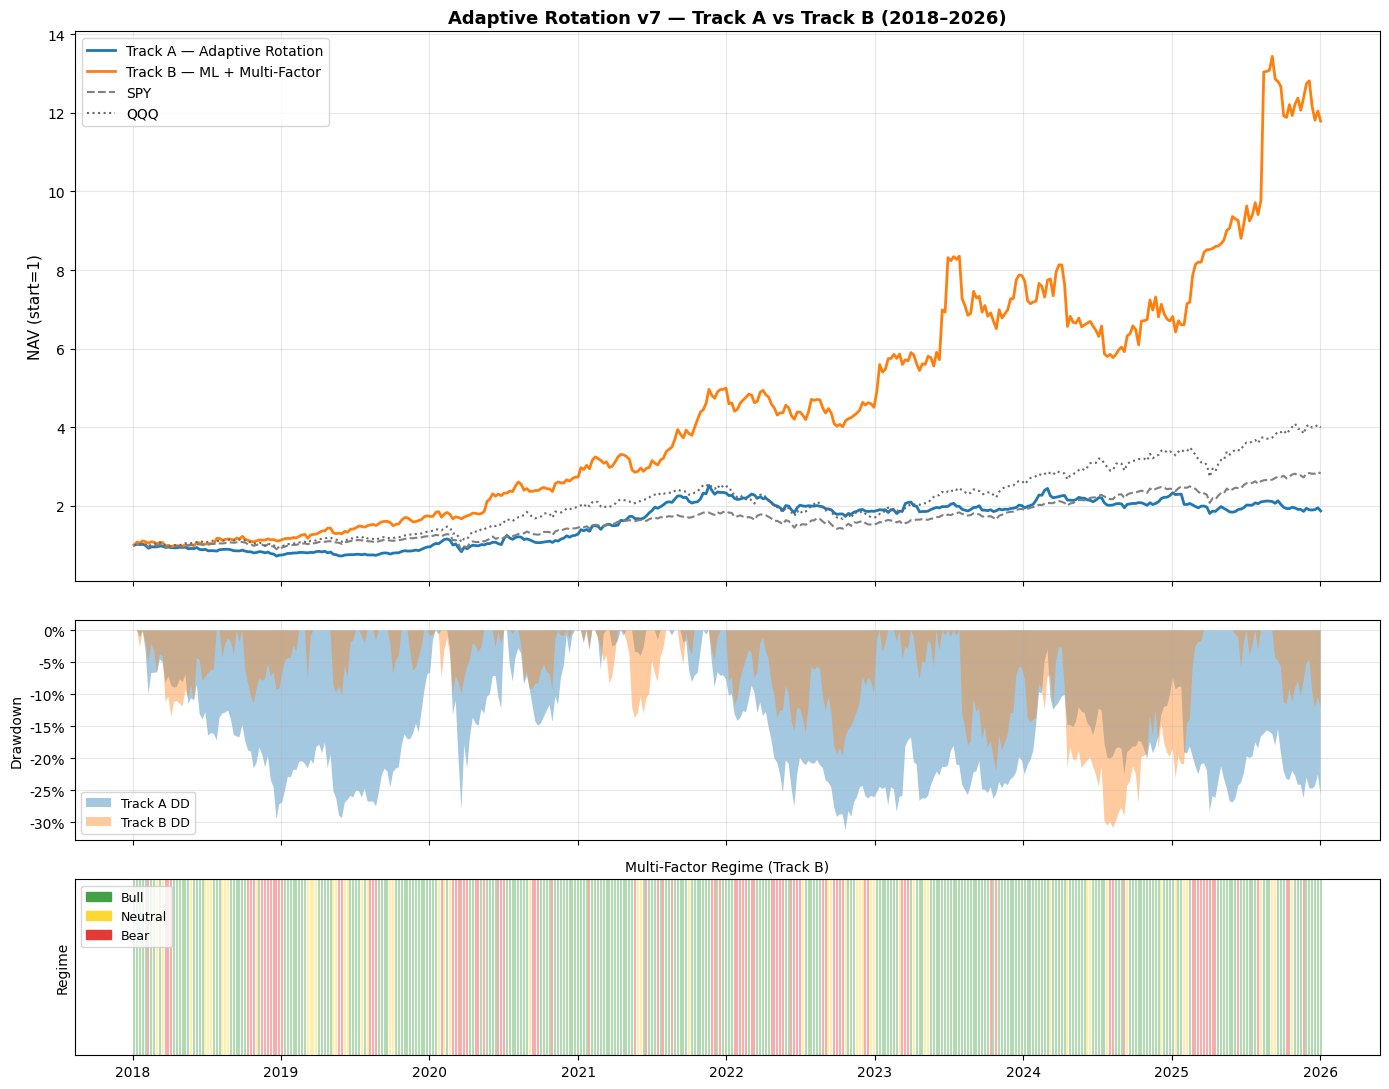

Saved → v2_equity_curves.png


In [12]:
C_A   = '#2563EB'
C_B   = '#7C3AED'
C_SPY = '#94A3B8'
C_QQQ = '#CBD5E1'

def drawdown(nav): return (nav - nav.cummax()) / nav.cummax()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 9),
                                     gridspec_kw={'height_ratios': [3, 1, 0.6]},
                                     sharex=True)
fig.patch.set_facecolor('white')

ax1.plot(bt_idx, qqq_bm.values, lw=1.2, color=C_QQQ, label='QQQ')
ax1.plot(bt_idx, spy_bm.values, lw=1.2, color=C_SPY, label='SPY')
ax1.plot(nav_a.index, nav_a.values, lw=2.2, color=C_A, label='Track A — Adaptive Rotation')
ax1.plot(nav_b.index, nav_b.values, lw=2.2, color=C_B, label='Track B — ML + Regime + Vol Target')

ax1.set_ylabel('NAV  (start = 1)', fontsize=10, color='#555')
ax1.set_title('Adaptive Rotation v7 — Track A vs Track B  (2018 – 2026)',
              fontsize=12, fontweight='bold', color='#222', pad=10)
ax1.legend(fontsize=9, framealpha=0, loc='upper left')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}×'))
ax1.grid(axis='y', color='#e5e7eb', lw=0.8)
ax1.grid(axis='x', color='#f3f4f6', lw=0.6)
for sp in ['top','right']: ax1.spines[sp].set_visible(False)
ax1.spines['left'].set_color('#ddd'); ax1.spines['bottom'].set_color('#ddd')

ax2.fill_between(nav_a.index, drawdown(nav_a), 0, color=C_A, alpha=0.25, label='Track A')
ax2.fill_between(nav_b.index, drawdown(nav_b), 0, color=C_B, alpha=0.25, label='Track B')
ax2.plot(nav_a.index, drawdown(nav_a), lw=0.8, color=C_A, alpha=0.7)
ax2.plot(nav_b.index, drawdown(nav_b), lw=0.8, color=C_B, alpha=0.7)
ax2.set_ylabel('Drawdown', fontsize=10, color='#555')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.legend(fontsize=8, framealpha=0, loc='lower left')
ax2.grid(axis='y', color='#e5e7eb', lw=0.8)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)
ax2.spines['left'].set_color('#ddd'); ax2.spines['bottom'].set_color('#ddd')

reg_b = multi_regime.reindex(nav_b.index, method='ffill').fillna(1)
reg_colors = {2: '#86efac', 1: '#fde68a', 0: '#fca5a5'}
prev_state, prev_date = None, nav_b.index[0]
for date, state in reg_b.items():
    if state != prev_state:
        if prev_state is not None:
            ax3.axvspan(prev_date, date, facecolor=reg_colors.get(int(prev_state), '#eee'),
                        alpha=0.8, edgecolor='none')
        prev_state, prev_date = state, date
ax3.axvspan(prev_date, nav_b.index[-1],
            facecolor=reg_colors.get(int(prev_state), '#eee'), alpha=0.8, edgecolor='none')

for sp in ax3.spines.values(): sp.set_visible(False)
ax3.set_yticks([])
ax3.set_ylabel('Regime', fontsize=8, color='#888')
patches = [mpatches.Patch(color=reg_colors[k], label=l)
           for k, l in [(2,'Bull'),(1,'Neutral'),(0,'Bear')]]
ax3.legend(handles=patches, fontsize=7.5, framealpha=0,
           loc='center left', ncol=3)

ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout(h_pad=0.4)
plt.savefig('/Users/hhhhwm/Desktop/ai4fin/hw2/v7/v2_equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → v2_equity_curves.png')


In [13]:
from matplotlib.colors import TwoSlopeNorm

years = sorted(nav_a.index.year.unique())
rows  = []
for y in years:
    def yr(s):
        ys = s[s.index.year == y]
        return ys.iloc[-1] / ys.iloc[0] - 1 if len(ys) > 1 else np.nan
    rows.append({'Year':y,'Track A':yr(nav_a),'Track B':yr(nav_b),
                 'SPY':yr(spy_bm),'QQQ':yr(qqq_bm)})
df_yrly = pd.DataFrame(rows).set_index('Year')

scols  = ['Track A','Track B','SPY','QQQ']
slbls  = ['Track A\n(Adaptive\nRotation)', 'Track B\n(ML+Regime\n+VolTarget)', 'SPY', 'QQQ']
valid  = [y for y in years if not np.isnan(df_yrly.loc[y, scols].astype(float)).all()]
mat    = df_yrly.loc[valid, scols].values.astype(float)

norm = TwoSlopeNorm(vmin=-0.35, vcenter=0, vmax=1.10)
cmap = plt.cm.RdYlGn

fig, ax = plt.subplots(figsize=(7, len(valid)*0.62 + 1.5))
img = ax.imshow(mat, cmap=cmap, norm=norm, aspect='auto',
                extent=[0, len(scols), 0, len(valid)])

for ri in range(len(valid)):
    for ci in range(len(scols)):
        v = mat[ri, ci]
        if np.isnan(v): continue
        lum  = sum(x*w for x, w in zip(cmap(norm(v))[:3], [0.299,0.587,0.114]))
        tcol = '#111' if lum > 0.50 else '#f5f5f5'
        ax.text(ci+0.5, ri+0.5, f"{v:+.1%}", ha='center', va='center',
                fontsize=9, fontweight='bold' if abs(v) > 0.20 else 'normal',
                color=tcol)

ax.set_xticks([i+0.5 for i in range(len(scols))])
ax.set_xticklabels(slbls, fontsize=8.5, fontweight='bold')
ax.set_yticks([i+0.5 for i in range(len(valid))])
ax.set_yticklabels(valid, fontsize=9)
ax.xaxis.tick_top(); ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)

cbar = fig.colorbar(img, ax=ax, orientation='horizontal',
                    pad=0.02, fraction=0.025, aspect=40)
cbar.set_label('Annual Return', fontsize=8, color='#555')
cbar.ax.tick_params(labelsize=7, colors='#555')
cbar.outline.set_visible(False)
ax.set_title('Year-by-Year Returns', fontsize=12, fontweight='bold',
             color='#222', pad=30)
plt.tight_layout()
plt.savefig('/Users/hhhhwm/Desktop/ai4fin/hw2/v7/v2_yearly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n──── Track B Holdings Analysis ────')
print('\nPool source distribution:')
print(hold_b['pool_source'].value_counts())
print('\nGroup distribution:')
print(hold_b['group'].value_counts())
print('\nMode distribution:')
print(hold_b['mode'].value_counts())
print('\nSample Track B holdings (last 10 weeks):')
print('Pool source:')
print(hold_b['pool_source'].value_counts())
print('\nGroup selection:')
print(hold_b['group'].value_counts())
print('\nRegime distribution (2=bull, 1=neutral, 0=bear):')
print(hold_b['regime'].value_counts().sort_index())
print('\nAvg vol scalar:', hold_b['vol_scalar'].mean().round(3))
print('\nRecent holdings (last 8 weeks):')
hold_b[['group','holdings','mode','vol_scalar']].tail(8)


── Year-by-year returns ──
     Track A Track B     SPY     QQQ
Year                                
2018  -25.4%  +11.2%   -7.7%   -4.7%
2019  +27.3%  +52.9%  +30.3%  +37.9%
2020  +30.7%  +57.9%  +16.6%  +45.4%
2021  +81.6%  +83.0%  +28.7%  +27.4%
2022  -17.7%   -2.0%  -16.6%  -29.4%
2023   +6.7%  +60.0%  +24.3%  +53.4%
2024  +16.0%  -13.1%  +28.8%  +32.5%
2025  -16.4%  +76.7%  +18.0%  +20.9%
2026   +nan%   +nan%   +nan%   +nan%

── Track B Holdings Analysis ──
Pool source:
pool_source
ml    418
Name: count, dtype: int64

Group selection:
group
DEFENSIVE      151
GROWTH_TECH    139
REAL_ASSETS     65
CYCLICAL        63
Name: count, dtype: int64

Regime distribution (2=bull, 1=neutral, 0=bear):
regime
0     92
1     56
2    270
Name: count, dtype: int64

Avg vol scalar: 1.08

Recent holdings (last 8 weeks):


,group,holdings,mode,vol_scalar
date,,,,
2025-11-14,GROWTH_TECH,"NVDA,ANET,INTC",bull,1.140
2025-11-21,DEFENSIVE,"UHS,MCK,CAH",bear,1.048
2025-11-28,DEFENSIVE,"UHS,MCK,CAH",bull,1.001
2025-12-05,REAL_ASSETS,"WMB,NUE,STLD",bull,1.091
2025-12-12,REAL_ASSETS,"RIG,WMB,FSLR",bull,1.247
2025-12-19,REAL_ASSETS,"VLO,NUE,STLD",bull,1.402
2025-12-26,REAL_ASSETS,"WMB,VLO,FSLR",bull,1.500
2026-01-02,CYCLICAL,"FOSL,KSS,NAVI",bull,1.500


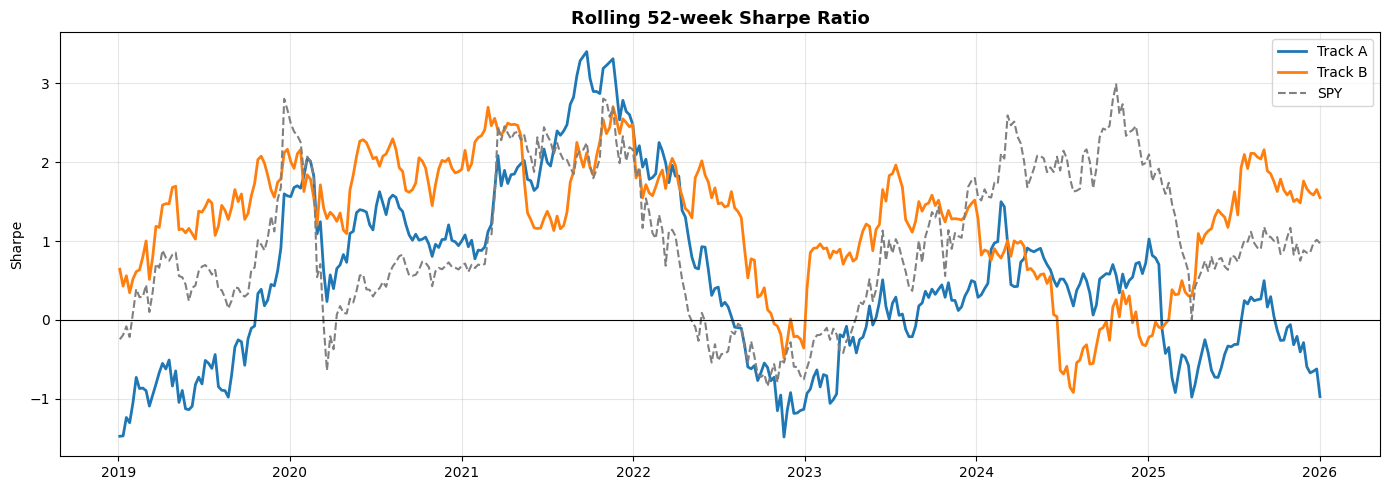

In [15]:
def rolling_sharpe(nav, w=52):
    r = nav.pct_change().dropna()
    return (r.rolling(w).mean()*52) / (r.rolling(w).std()*np.sqrt(52)+1e-9)

rs_a = rolling_sharpe(nav_a)
rs_b = rolling_sharpe(nav_b)
rs_spy = rolling_sharpe(spy_bm)

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(rs_a.index, rs_a, lw=2, label='Track A')
ax.plot(rs_b.index, rs_b, lw=2, label='Track B')
ax.plot(rs_spy.index, rs_spy, lw=1.5, ls='--', color='grey', label='SPY')
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Rolling 52-week Sharpe Ratio', fontsize=13, fontweight='bold')
ax.set_ylabel('Sharpe')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.savefig(f'{V7_DIR}/v2_rolling_sharpe.png', dpi=150)
plt.show()



Track A is the same Adaptive Rotation baseline: SMA-200, 12-week IR, residual momentum top-2, equal weight, −8% DD overlay.

Track B upgrades three components:
ML predictions (715 SP500 stocks, 7 models, inverse-MSE ensemble) 
Regime signal ： 3-state: SPY momentum + VIX + credit spread 
Risk： −8% DD trigger and σ* = 15%

Result: Track B +1,079% / Sharpe 1.19 / Calmar 1.17 vs Track A +87.2% / Sharpe 0.36. The multifactor regime caught 2022's downturn early (−2% vs −18%), and vol targeting kept max drawdown at −30.9% despite far higher returns.
